In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

In [46]:
df = pd.read_csv("ai4i2020.csv")

print("Dataset berhasil dimuat!")
print("Ukuran dataset:", df.shape)

Dataset berhasil dimuat!
Ukuran dataset: (10000, 14)


In [47]:
X = df[
    [
        "Type",
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]"
    ]
]

y = df["Machine failure"]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (10000, 6)
Shape y: (10000,)


In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (8000, 6)
X_test : (2000, 6)
y_train: (8000,)
y_test : (2000,)


In [49]:
categorical_cols = ["Type"]

numerical_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

In [50]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [51]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing berhasil!")
print("X_train_processed:", X_train_processed.shape)
print("X_test_processed :", X_test_processed.shape)

Preprocessing berhasil!
X_train_processed: (8000, 8)
X_test_processed : (2000, 8)


In [52]:
models = {
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
}

print("3 model berhasil dibuat!")

3 model berhasil dibuat!


In [53]:
for name, model in models.items():
    model.fit(X_train_processed, y_train)

print("3 model berhasil dilatih!")

3 model berhasil dilatih!


In [54]:
results = []

for name, model in models.items():

    y_train_pred = model.predict(X_train_processed)
    y_test_pred = model.predict(X_test_processed)
    y_test_prob = model.predict_proba(X_test_processed)[:, 1]

    train_acc = accuracy_score(
        y_train,
        y_train_pred
    )

    test_acc = accuracy_score(
        y_test,
        y_test_pred
    )

    precision = precision_score(
        y_test,
        y_test_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_test_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_test_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_test,
        y_test_prob
    )

    results.append({
        "Model": name,
        "Train Acc": train_acc,
        "Test Acc": test_acc,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "AUC-ROC": auc
    })

results_df = pd.DataFrame(results)

display(results_df)

,Model,Train Acc,Test Acc,Precision,Recall,F1-Score,AUC-ROC
0,Decision Tree,1.0000,0.9785,0.686567,0.676471,0.681481,0.832801
1,Logistic Regression,0.9705,0.9675,0.636364,0.102941,0.177215,0.899388
2,Random Forest,1.0000,0.9815,0.897436,0.514706,0.654206,0.970858


In [55]:
results_display = results_df.copy()

metric_cols = [
    "Train Acc",
    "Test Acc",
    "Precision",
    "Recall",
    "F1-Score",
    "AUC-ROC"
]

results_display[metric_cols] = results_display[
    metric_cols
].round(4)

display(results_display)

,Model,Train Acc,Test Acc,Precision,Recall,F1-Score,AUC-ROC
0,Decision Tree,1.0000,0.9785,0.6866,0.6765,0.6815,0.8328
1,Logistic Regression,0.9705,0.9675,0.6364,0.1029,0.1772,0.8994
2,Random Forest,1.0000,0.9815,0.8974,0.5147,0.6542,0.9709


In [56]:
best_model_name = results_df.loc[
    results_df["F1-Score"].idxmax(),
    "Model"
]

best_model = models[best_model_name]

print("Model terbaik berdasarkan F1-Score:")
print(best_model_name)

Model terbaik berdasarkan F1-Score:
Decision Tree


In [57]:
y_pred_best = best_model.predict(X_test_processed)

cm = confusion_matrix(
    y_test,
    y_pred_best
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1911   21]
 [  22   46]]


In [58]:
feature_names = preprocessor.get_feature_names_out()

if hasattr(best_model, "feature_importances_"):

    importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": best_model.feature_importances_
    })

    importance = importance.sort_values(
        "Importance",
        ascending=False
    )

    display(importance)

else:

    print(
        "Model terbaik tidak menyediakan "
        "feature_importances_."
    )

,Feature,Importance
3,num__Torque [Nm],0.363672
0,num__Air temperature [K],0.207028
4,num__Tool wear [min],0.151233
2,num__Rotational speed [rpm],0.142467
1,num__Process temperature [K],0.110956
6,cat__Type_L,0.017742
7,cat__Type_M,0.004979
5,cat__Type_H,0.001922


In [59]:
if hasattr(best_model, "feature_importances_"):

    top5_features = importance.head(5)

    print("Top 5 Feature Importance:")
    display(top5_features)

Top 5 Feature Importance:


,Feature,Importance
3,num__Torque [Nm],0.363672
0,num__Air temperature [K],0.207028
4,num__Tool wear [min],0.151233
2,num__Rotational speed [rpm],0.142467
1,num__Process temperature [K],0.110956


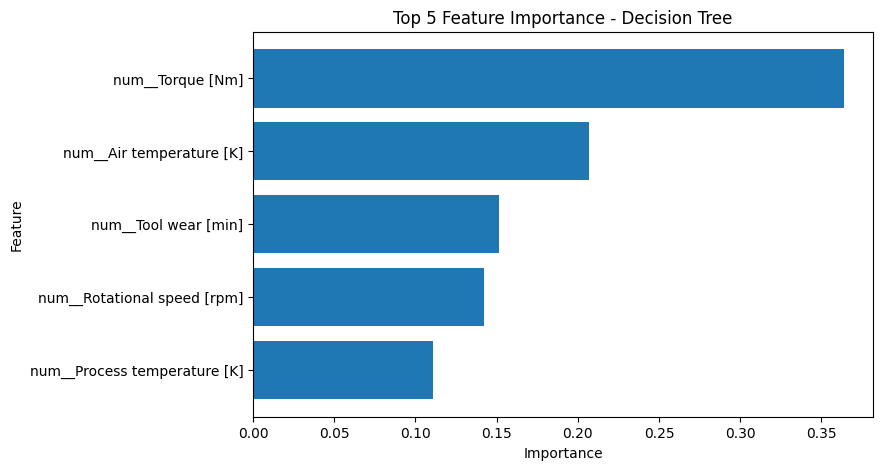

In [60]:
if hasattr(best_model, "feature_importances_"):

    plt.figure(figsize=(8, 5))

    plt.barh(
        top5_features["Feature"],
        top5_features["Importance"]
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(
        f"Top 5 Feature Importance - {best_model_name}"
    )

    plt.gca().invert_yaxis()

    plt.show()

In [61]:
model_package = {
    "preprocessor": preprocessor,
    "model": best_model,
    "features": [
        "Type",
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]"
    ],
    "target": "Machine failure",
    "model_name": best_model_name
}

joblib.dump(
    model_package,
    "supervised_best_model.pkl"
)

print("Model berhasil diexport!")
print("File: supervised_best_model.pkl")

Model berhasil diexport!
File: supervised_best_model.pkl


In [62]:
import os

print(
    "File tersedia:",
    os.path.exists("supervised_best_model.pkl")
)

if os.path.exists("supervised_best_model.pkl"):
    print(
        "Ukuran file:",
        round(
            os.path.getsize("supervised_best_model.pkl") / 1024,
            2
        ),
        "KB"
    )

File tersedia: True
Ukuran file: 28.11 KB


In [63]:
import os

print(
    "File tersedia:",
    os.path.exists("supervised_best_model.pkl")
)

if os.path.exists("supervised_best_model.pkl"):
    print(
        "Ukuran file:",
        round(
            os.path.getsize("supervised_best_model.pkl") / 1024,
            2
        ),
        "KB"
    )

File tersedia: True
Ukuran file: 28.11 KB


In [64]:
loaded_package = joblib.load(
    "supervised_best_model.pkl"
)

print("Model berhasil di-load kembali!")
print("Nama model:", loaded_package["model_name"])
print("Target:", loaded_package["target"])

Model berhasil di-load kembali!
Nama model: Decision Tree
Target: Machine failure


In [65]:
loaded_preprocessor = loaded_package["preprocessor"]
loaded_model = loaded_package["model"]

sample_data = X_test.head(5)

sample_processed = loaded_preprocessor.transform(
    sample_data
)

sample_prediction = loaded_model.predict(
    sample_processed
)

print("Data sample:")
display(sample_data)

print("Hasil prediksi Machine Failure:")
print(sample_prediction)

Data sample:


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
2997,L,300.5,309.8,1345,62.7,153
4871,L,303.7,312.4,1513,40.1,135
3858,L,302.5,311.4,1559,37.6,209
951,H,295.6,306.3,1509,35.8,60
6463,H,300.5,310.0,1358,60.4,102


Hasil prediksi Machine Failure:
[0 0 0 0 0]


In [66]:
import joblib
import os
from google.colab import files

# Menyiapkan package model
model_package = {
    "preprocessor": preprocessor,
    "model": best_model,
    "features": [
        "Type",
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]"
    ],
    "target": "Machine failure",
    "model_name": best_model_name
}

# Export model ke .pkl
file_name = "supervised_best_model.pkl"

joblib.dump(
    model_package,
    file_name
)

# Cek file
if os.path.exists(file_name):
    file_size = os.path.getsize(file_name) / 1024

    print("Model berhasil diexport!")
    print("File:", file_name)
    print("File tersedia:", True)
    print("Ukuran file:", round(file_size, 2), "KB")

    # Download ke laptop
    files.download(file_name)

else:
    print("File gagal dibuat!")

Model berhasil diexport!
File: supervised_best_model.pkl
File tersedia: True
Ukuran file: 28.11 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>